In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [1]:
# Set visualization style
plt.style.use('ggplot')  # Modern and clean style
sns.set_palette('pastel')  # Soft color palette
%matplotlib inline

In [2]:
# Load datasets (replace with your actual file paths)
train_path = "train.csv"  
test_path = "test.csv"    

In [3]:
try:
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    print("✅ Data loaded successfully")
except Exception as e:
    print(f"❌ Error loading data: {e}")
    raise

✅ Data loaded successfully


In [4]:
print("Removing Duplicates")
print("Duplicate values in train_df: ",train_df.duplicated().sum())
# print("Duplicate values in test_df: ",test_df.duplicated().sum())
if(train_df.duplicated().sum()>0):
    train_df.drop_duplicates(inplace=True)
    train_df.reset_index(drop=True,inplace=True)
# if(test_df.duplicated().sum()>0):
#     test_df.drop_duplicates(inplace=True)
#     test_df.reset_index(drop=True,inplace=True)

Removing Duplicates
Duplicate values in train_df:  0


In [5]:
print("\n=== Data Overview ===")
print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print("\nTraining data sample:")
display(train_df.head(3))


=== Data Overview ===
Training data shape: (17996, 17)
Test data shape: (7713, 16)

Training data sample:


,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,Bruno Mars,That's What I Like (feat. Gucci Mane),60.0,0.854,0.564,1.0,-4.964,1,0.0485,0.0171,NaN,0.0849,0.899,134.071,234596.0,4,5
1,Boston,Hitch a Ride,54.0,0.382,0.814,3.0,-7.230,1,0.0406,0.0011,0.004010,0.1010,0.569,116.454,251733.0,4,10
2,The Raincoats,No Side to Fall In,35.0,0.434,0.614,6.0,-8.334,1,0.0525,0.4860,0.000196,0.3940,0.787,147.681,109667.0,4,6


In [6]:
numerical_features = train_df.select_dtypes(include=np.number).columns.tolist()
categorical_features = ['Artist Name', 'Track Name', 'key', 'mode', 'time_signature']
#required_col are for normalizing
required_col=numerical_features.copy()
for col in categorical_features:
    if(col in required_col):
        required_col.remove(col)
if 'Class' in numerical_features:
    numerical_features.remove('Class')
if 'Class' in required_col:
    required_col.remove('Class')

print("\nNumerical features:", numerical_features)
print("Categorical features:", categorical_features)


Numerical features: ['Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature']
Categorical features: ['Artist Name', 'Track Name', 'key', 'mode', 'time_signature']


In [7]:
# ======================
# IMPROVED MISSING VALUE HANDLING 
# ======================
# Make copies of our data to avoid SettingWithCopy warnings
train_df = train_df.copy()
test_df = test_df.copy()

# Make copy of numerical features and remove 'key'
features_to_impute = numerical_features.copy()
if 'key' in features_to_impute:
    features_to_impute.remove('key')

print("\n=== Handling Missing Values with Smart Imputation ===")

# Track original missing values
original_train_missing = train_df[features_to_impute + ['key']].isnull().sum().sum()
original_test_missing = test_df[features_to_impute + ['key']].isnull().sum().sum()

print(f"\nOriginal missing values:\nTrain: {original_train_missing}\nTest: {original_test_missing}")

# 1. NUMERICAL FEATURES IMPUTATION
print("\n=== Numerical Features Imputation ===")
for col in features_to_impute:
    if col in train_df.columns and train_df[col].isnull().sum() > 0:
        # Get valid features for prediction
        predictors = [c for c in features_to_impute if c != col and c in train_df.columns]
        train_valid = train_df.dropna(subset=[col] + predictors)
        
        if not predictors or train_valid.empty:
            print(f"{col}: Using median (not enough data for regression)")
            median_val = train_df[col].median()
            train_df[col] = train_df[col].fillna(median_val)
            test_df[col] = test_df[col].fillna(median_val)
            continue
            
        # Split to evaluate regression
        X_train, X_val, y_train, y_val = train_test_split(
            train_valid[predictors], train_valid[col], 
            test_size=0.2, random_state=42)
        
        model = LinearRegression()
        model.fit(X_train, y_train)
        score = model.score(X_val, y_val)
        rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_val)))
        
        if score > 0.3:  # Only use if decent R-squared
            print(f"{col}: Regression (R²={score:.2f}, RMSE={rmse:.2f})")
            
            # Impute train
            train_missing = train_df[train_df[col].isnull() & train_df[predictors].notnull().all(axis=1)]
            if not train_missing.empty:
                train_df.loc[train_missing.index, col] = model.predict(train_missing[predictors])
            
            # Impute test
            test_missing = test_df[test_df[col].isnull() & test_df[predictors].notnull().all(axis=1)]
            if not test_missing.empty:
                test_df.loc[test_missing.index, col] = model.predict(test_missing[predictors])
        else:
            print(f"{col}: Using median (poor regression R²={score:.2f})")
            median_val = train_df[col].median()
            train_df[col] = train_df[col].fillna(median_val)
            test_df[col] = test_df[col].fillna(median_val)
        
        # Final fallback for any remaining missing
        if train_df[col].isnull().sum() > 0:
            train_df[col] = train_df[col].fillna(train_df[col].median())
        if test_df[col].isnull().sum() > 0:
            test_df[col] = test_df[col].fillna(train_df[col].median())  # Use train median

# 2. CATEGORICAL 'key' IMPUTATION
if 'key' in train_df.columns:
    print("\n=== Categorical 'key' Imputation ===")
    key_predictors = [c for c in features_to_impute if train_df[c].isnull().sum() == 0]
    
    if train_df['key'].isnull().sum() > 0:
        train_known = train_df[train_df['key'].notnull() & train_df[key_predictors].notnull().all(axis=1)]
        
        if not train_known.empty:
            # Evaluate model
            X_train, X_val, y_train, y_val = train_test_split(
                train_known[key_predictors], train_known['key'],
                test_size=0.2, random_state=42)
            
            clf = RandomForestClassifier(n_estimators=100, random_state=42, 
                                       class_weight='balanced', n_jobs=-1)
            clf.fit(X_train, y_train)
            val_acc = accuracy_score(y_val, clf.predict(X_val))
            
            if val_acc > 0.5:  # Only use if decent accuracy
                print(f"Key: RF imputation (Val Acc: {val_acc:.2f})")
                
                # Impute train
                train_missing = train_df[train_df['key'].isnull() & train_df[key_predictors].notnull().all(axis=1)]
                if not train_missing.empty:
                    train_df.loc[train_missing.index, 'key'] = clf.predict(train_missing[key_predictors])
                
                # Impute test
                test_missing = test_df[test_df['key'].isnull() & test_df[key_predictors].notnull().all(axis=1)]
                if not test_missing.empty:
                    test_df.loc[test_missing.index, 'key'] = clf.predict(test_missing[key_predictors])
            else:
                print(f"Key: Using mode (poor RF accuracy: {val_acc:.2f})")
                mode_val = train_df['key'].mode()[0]
                train_df['key'] = train_df['key'].fillna(mode_val)
                test_df['key'] = test_df['key'].fillna(mode_val)
        else:
            print("Key: Using mode (no training data available)")
            mode_val = train_df['key'].mode()[0]
            train_df['key'] = train_df['key'].fillna(mode_val)
            test_df['key'] = test_df['key'].fillna(mode_val)

# 3. FINAL VALIDATION
print("\n=== Imputation Results ===")
print(f"Train missing values before: {original_train_missing}")
print(f"Train missing values after: {train_df[features_to_impute + ['key']].isnull().sum().sum()}")
print(f"\nTest missing values before: {original_test_missing}")
print(f"Test missing values after: {test_df[features_to_impute + ['key']].isnull().sum().sum()}")

# Add key back to numerical features if needed
if 'key' not in numerical_features:
    numerical_features.append('key')

assert train_df.isnull().sum().sum() == 0, "Missing values remain in training data"
assert test_df.isnull().sum().sum() == 0, "Missing values remain in test data"
print("\n✅ All missing values successfully imputed!")


=== Handling Missing Values with Smart Imputation ===

Original missing values:
Train: 6819
Test: 2944

=== Numerical Features Imputation ===
Popularity: Using median (poor regression R²=0.06)
instrumentalness: Using median (poor regression R²=0.18)

=== Categorical 'key' Imputation ===
Key: Using mode (poor RF accuracy: 0.31)

=== Imputation Results ===
Train missing values before: 6819
Train missing values after: 0

Test missing values before: 2944
Test missing values after: 0

✅ All missing values successfully imputed!


In [8]:
#############################################No need to run as there are no nan in categories
# for col in categorical_features:
#     if col in train_df.columns:
#         train_df[col].fillna('Unknown')
#         if col in test_df.columns:
#             test_df[col].fillna('Unknown')

In [9]:
# Verify no missing values remain
print("\nMissing values after imputation:")
print(train_df.isnull().sum())
print("Training:", train_df.isnull().sum().sum())
print("Test:", test_df.isnull().sum().sum())


Missing values after imputation:
Artist Name           0
Track Name            0
Popularity            0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
duration_in min/ms    0
time_signature        0
Class                 0
dtype: int64
Training: 0
Test: 0


In [10]:
train_df.describe()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
count,17996.000000,17996.000000,17996.000000,17996.000000,17996.000000,17996.000000,17996.000000,17996.000000,17996.000000,17996.000000,17996.000000,17996.000000,1.799600e+04,17996.000000,17996.000000
mean,44.499944,0.543433,0.662777,6.069682,-7.910660,0.636753,0.079707,0.247082,0.135326,0.196170,0.486208,122.623294,2.007445e+05,3.924039,6.695821
std,17.218613,0.166268,0.235373,3.030700,4.049151,0.480949,0.083576,0.310632,0.274791,0.159212,0.240195,29.571527,1.119891e+05,0.361618,3.206073
min,1.000000,0.059600,0.000020,1.000000,-39.952000,0.000000,0.022500,0.000000,0.000001,0.011900,0.018300,30.557000,5.016500e-01,1.000000,0.000000
25%,33.000000,0.432000,0.509000,4.000000,-9.538000,0.000000,0.034800,0.004300,0.000294,0.097500,0.297000,99.620750,1.663370e+05,4.000000,5.000000
50%,44.000000,0.545000,0.700000,7.000000,-7.016000,1.000000,0.047400,0.081400,0.003910,0.129000,0.481000,120.065500,2.091600e+05,4.000000,8.000000
75%,56.000000,0.659000,0.860000,8.000000,-5.189000,1.000000,0.083000,0.434000,0.056600,0.258000,0.672000,141.969250,2.524900e+05,4.000000,10.000000
max,100.000000,0.989000,1.000000,11.000000,1.355000,1.000000,0.955000,0.996000,0.996000,1.000000,0.986000,217.416000,1.477187e+06,5.000000,10.000000


In [11]:
test_df.describe()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature
count,7713.000000,7713.000000,7713.000000,7713.000000,7713.000000,7713.000000,7713.000000,7713.000000,7713.000000,7713.000000,7713.000000,7713.000000,7.713000e+03,7713.000000
mean,44.939583,0.548110,0.663465,6.037340,-7.840913,0.646311,0.080052,0.241400,0.128931,0.198331,0.489787,122.976657,1.994245e+05,3.918060
std,17.144469,0.164906,0.234822,3.082023,3.982363,0.478145,0.084228,0.308006,0.268269,0.161399,0.237996,29.723547,1.131100e+05,0.369727
min,1.000000,0.000000,0.000020,1.000000,-36.544000,0.000000,0.000000,0.000000,0.000001,0.016900,0.000000,0.000000,6.874500e-01,0.000000
25%,34.000000,0.440000,0.510000,4.000000,-9.527000,0.000000,0.034800,0.004600,0.000333,0.098500,0.306000,99.678000,1.655660e+05,4.000000
50%,44.000000,0.549000,0.699000,7.000000,-6.917000,1.000000,0.047000,0.075600,0.003910,0.131000,0.484000,121.140000,2.088890e+05,4.000000
75%,56.000000,0.661000,0.863000,9.000000,-5.184000,1.000000,0.083300,0.406000,0.045500,0.260000,0.672000,141.984000,2.506940e+05,4.000000
max,100.000000,0.975000,1.000000,11.000000,0.878000,1.000000,0.960000,0.995000,0.987000,0.992000,0.982000,249.438000,1.561133e+06,5.000000


In [12]:
# ======================
# 4. ENCODE CATEGORICAL FEATURES
# ======================

print("\n=== Encoding Categorical Features ===")

for col in ["Artist Name","Track Name"]:
    if col in train_df.columns:
        # Combine train and test for consistent encoding
        combined = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
        print(combined)
        le = LabelEncoder().fit(combined)
        
        train_df[col] = le.transform(train_df[col].astype(str))
        test_df[col] = le.transform(test_df[col].astype(str))
        print(f"Encoded {col}")


=== Encoding Categorical Features ===
0                  Bruno Mars
1                      Boston
2               The Raincoats
3                        Deno
4       Red Hot Chili Peppers
                ...          
7708              Dudu Aharon
7709            Elephant Tree
7710        Shankar Mahadevan
7711            Talking Heads
7712             Marlon Craft
Name: Artist Name, Length: 25709, dtype: object
Encoded Artist Name
0       That's What I Like (feat. Gucci Mane)
1                                Hitch a Ride
2                          No Side to Fall In
3                  Lingo (feat. J.I & Chunkz)
4           Nobody Weird Like Me - Remastered
                        ...                  
7708                        ◊ë◊ó◊ï◊® ◊®◊í◊ô◊©
7709                                   Echoes
7710                               Man Mohini
7711      Life During Wartime - 2005 Remaster
7712                              Lot To Give
Name: Track Name, Length: 25709, dtype: object
Encoded Tr


=== Starting Exploratory Data Analysis ===


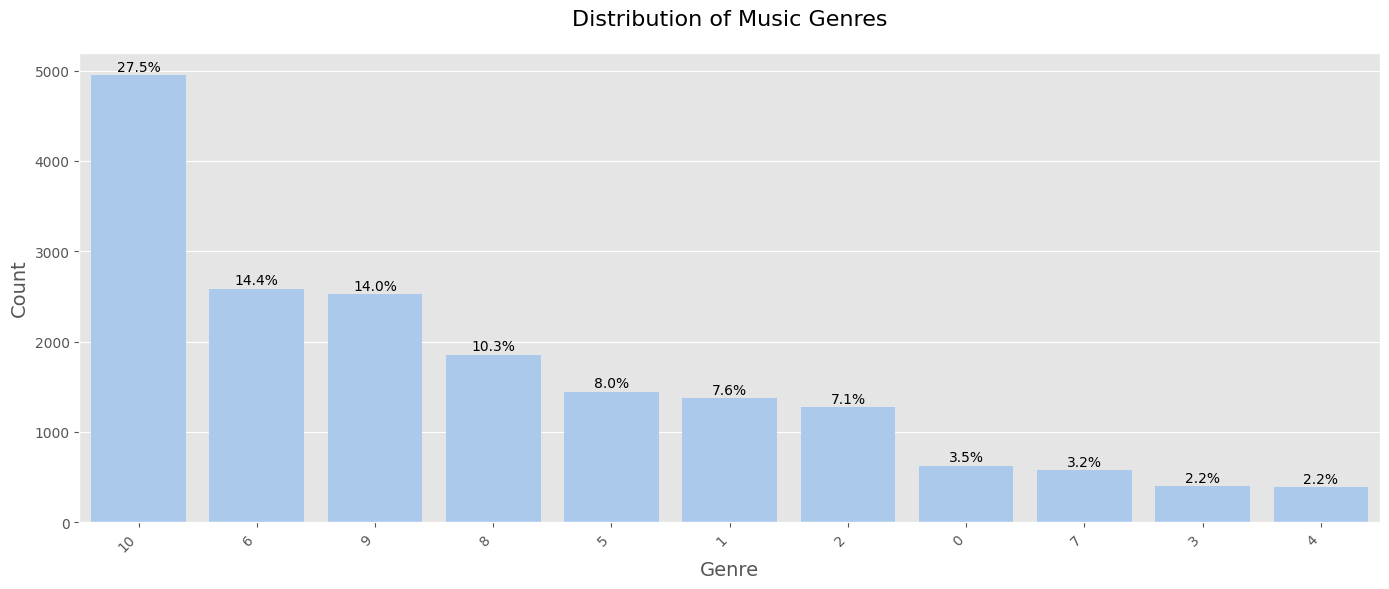

In [13]:
print("\n=== Starting Exploratory Data Analysis ===")

# 5.1 Genre Distribution
plt.figure(figsize=(14,6))
ax = sns.countplot(data=train_df, x='Class', order=train_df['Class'].value_counts().index)

plt.title('Distribution of Music Genres', fontsize=16, pad=20)
plt.xlabel('Genre', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, ha='right')

# Add percentage labels
total = len(train_df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 50,
            f'{height/total:.1%}',
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()



=== Feature Distributions ===


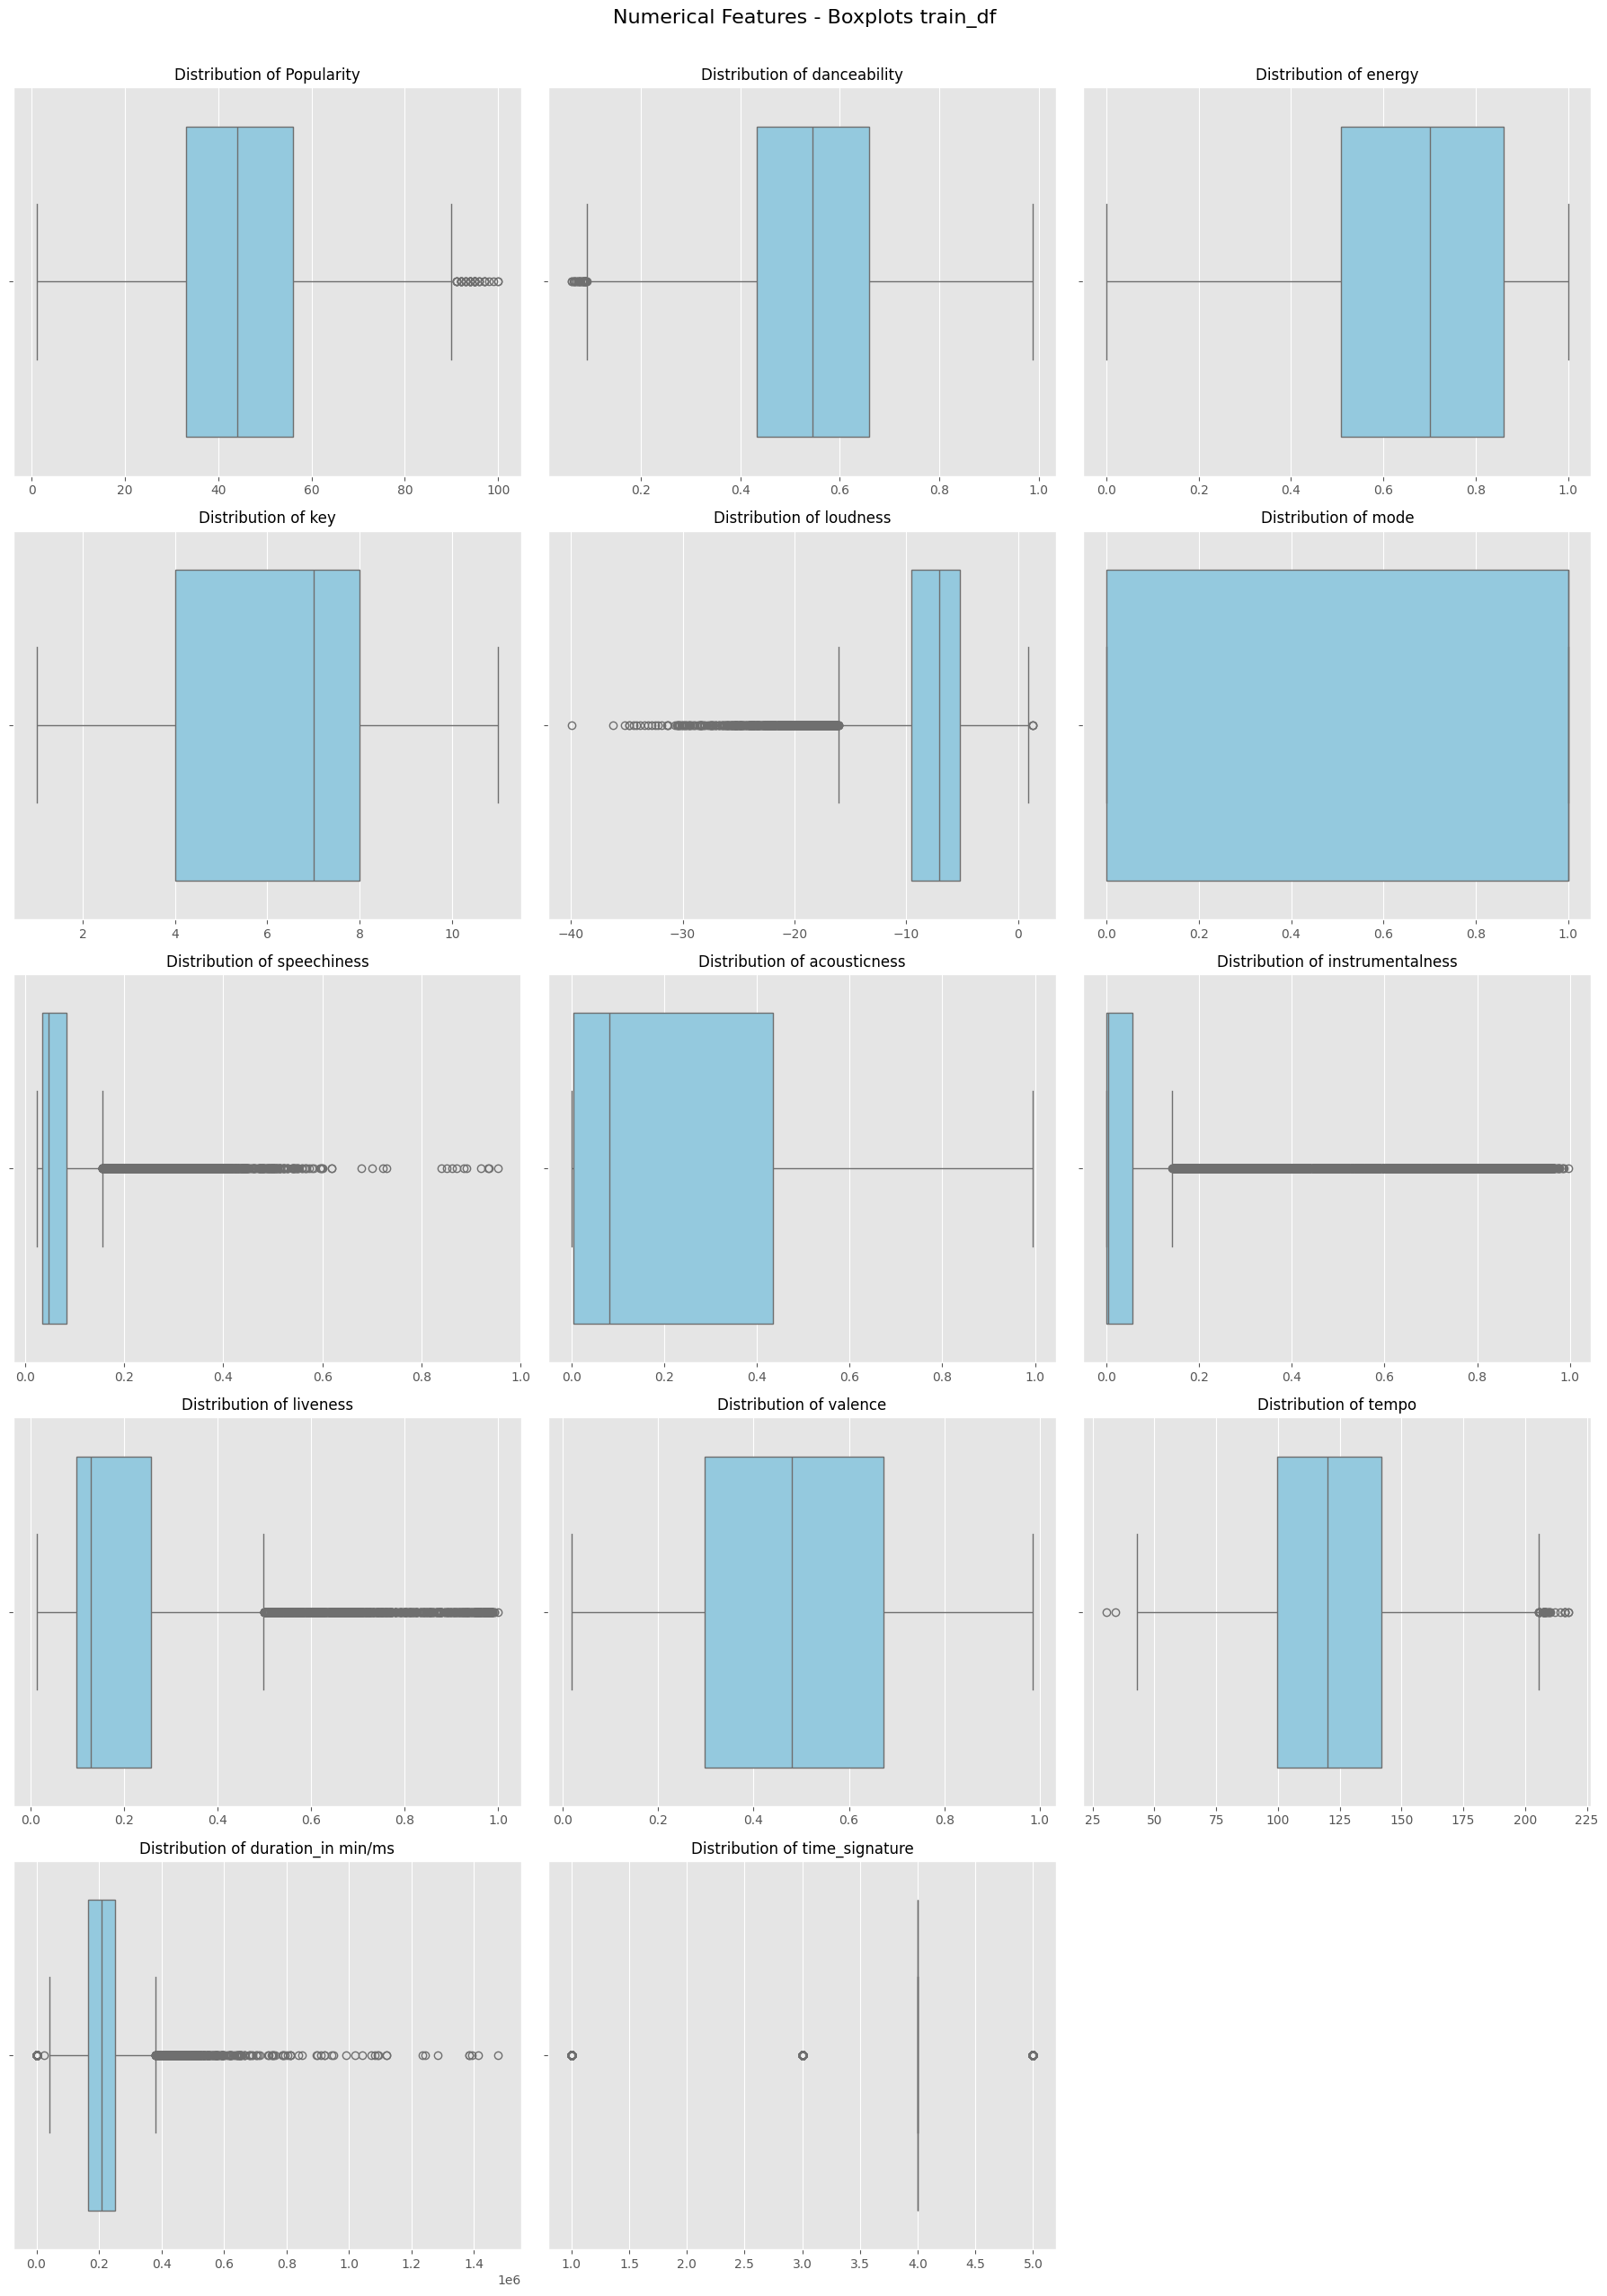

************************************************** Test Boxplot **************************************************


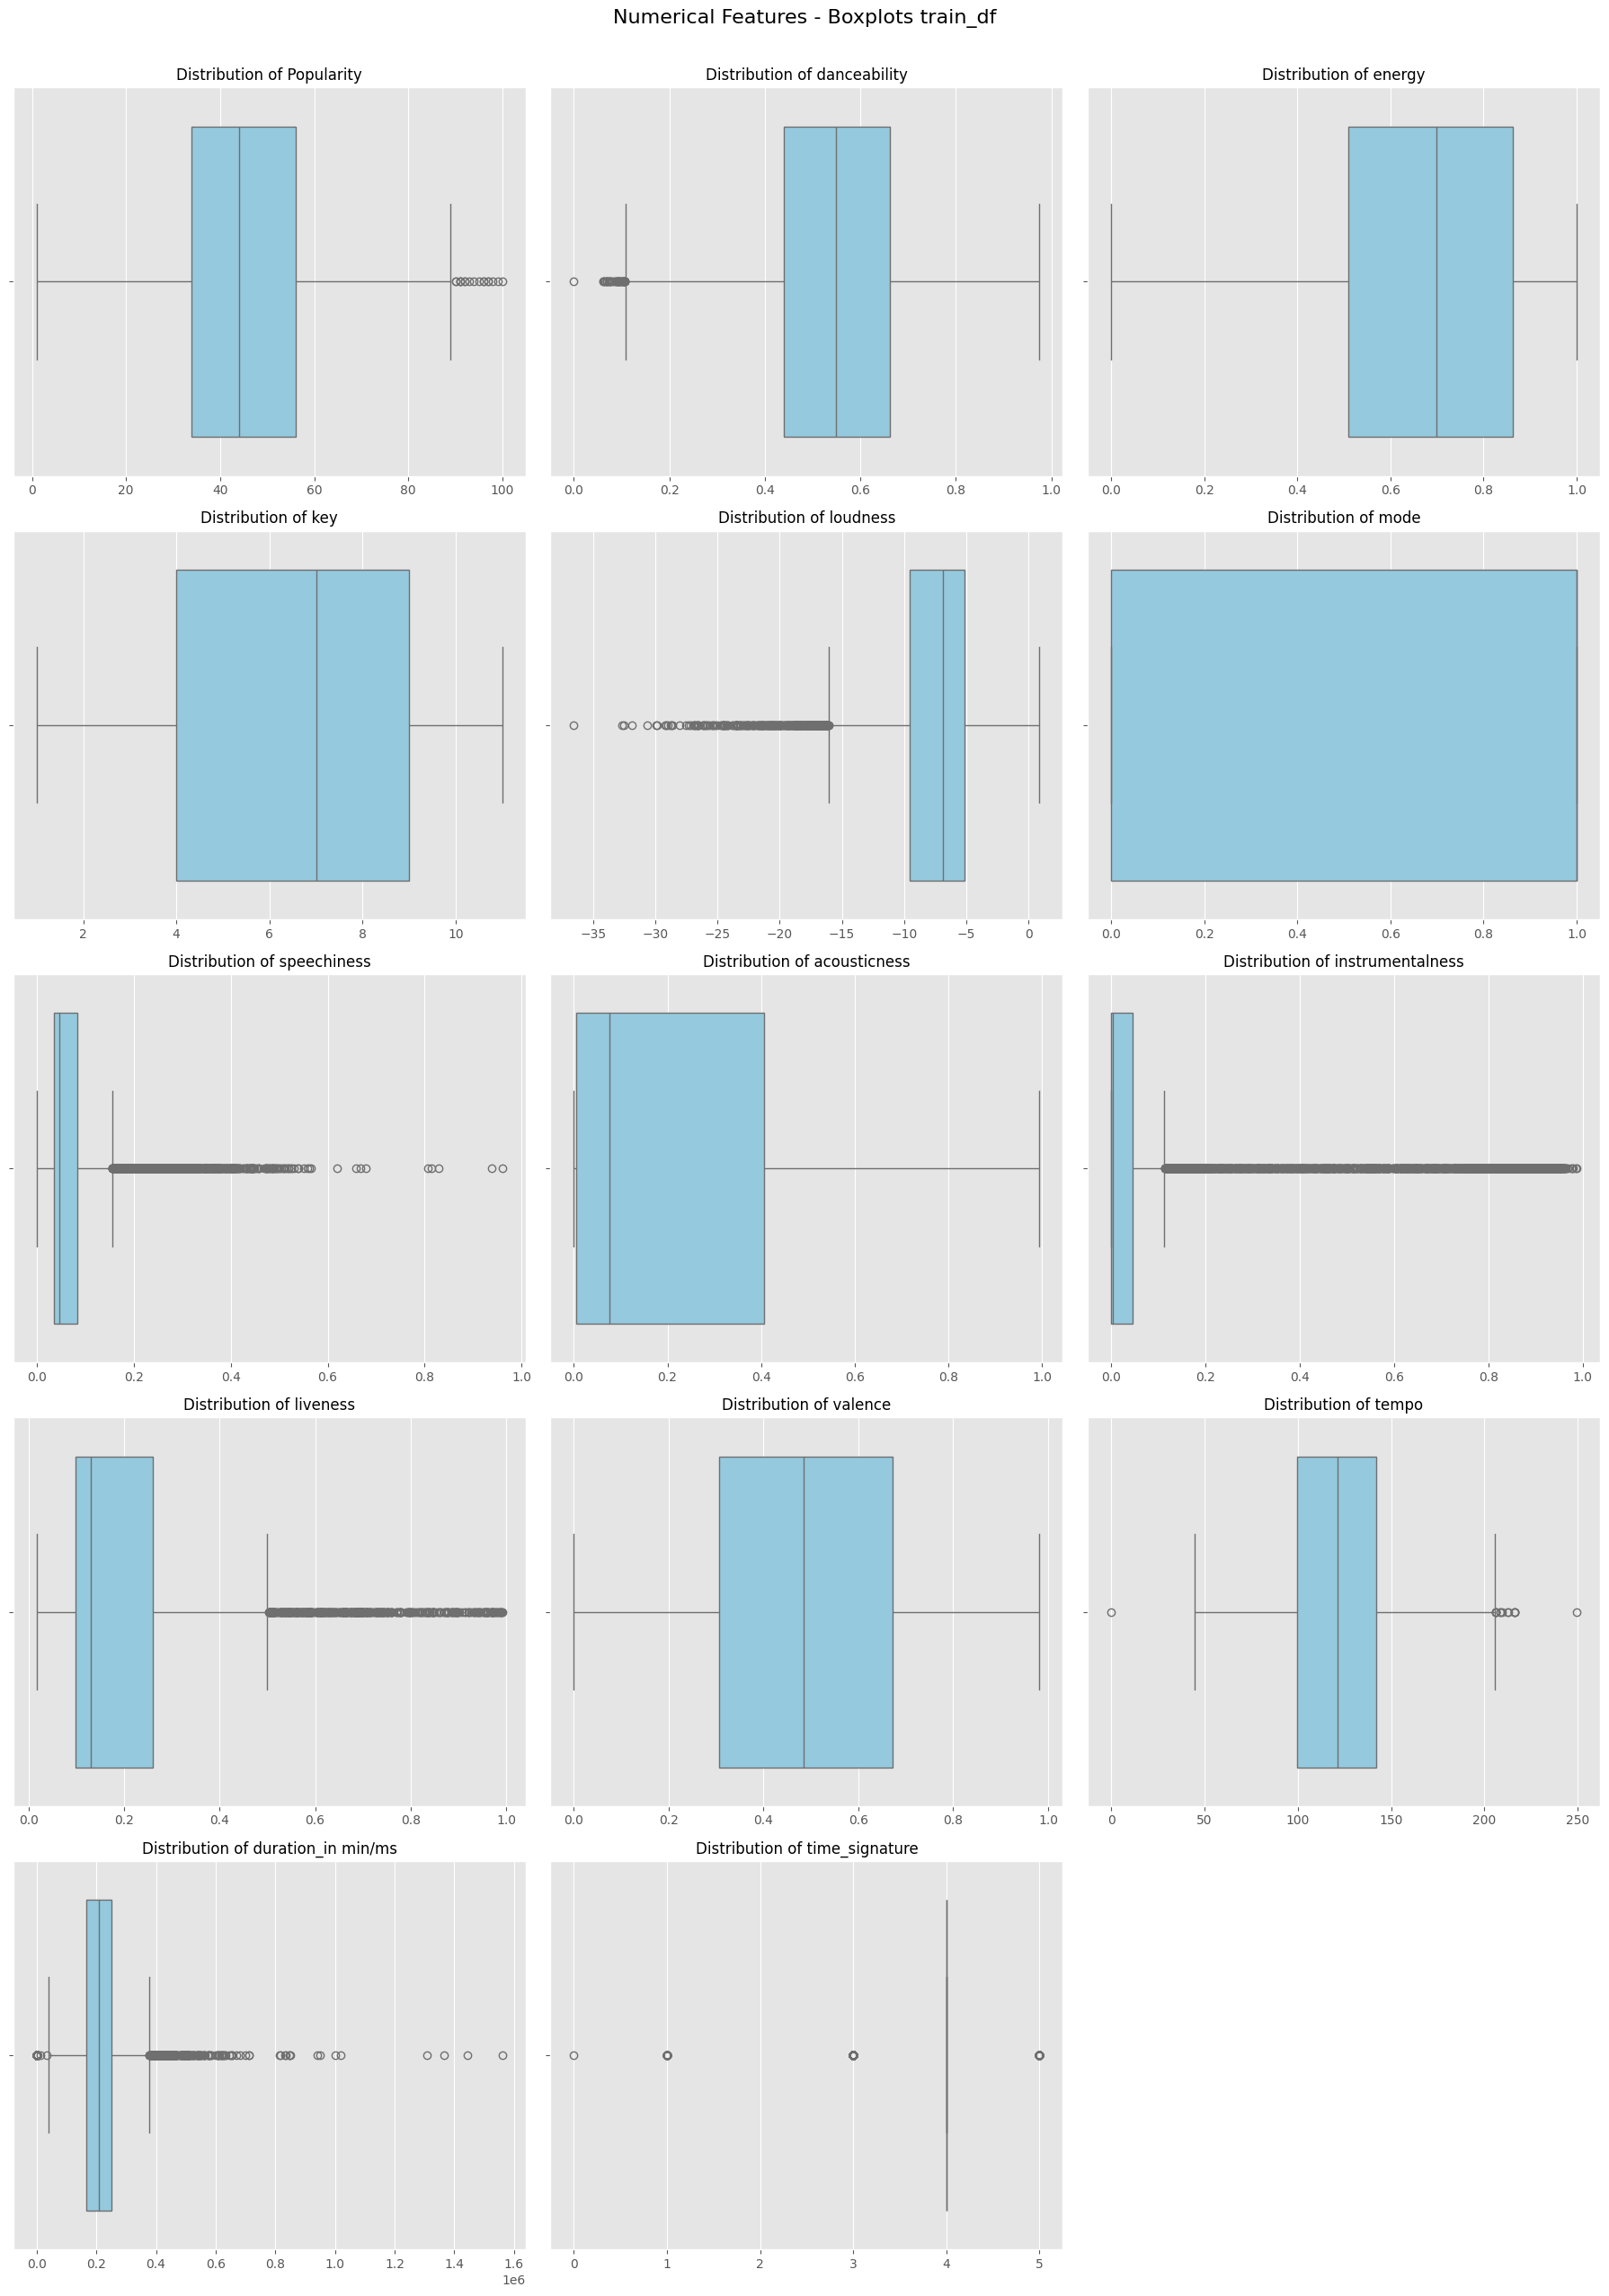

In [14]:
# 5.2 Feature Distributions
print("\n=== Feature Distributions ===")

# Create subplots for numerical features
n_cols = 3
n_rows = int(np.ceil(len(numerical_features) / n_cols))

# Boxplots
plt.figure(figsize=(18, 5*n_rows))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=train_df[col], color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('')
plt.tight_layout()
plt.suptitle('Numerical Features - Boxplots train_df', y=1.02, fontsize=16)
plt.show()

n_cols = 3
n_rows = int(np.ceil(len(numerical_features) / n_cols))
print("**"*25,"Test Boxplot","**"*25)
# Boxplots
plt.figure(figsize=(18, 5*n_rows))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=test_df[col], color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('')
plt.tight_layout()
plt.suptitle('Numerical Features - Boxplots train_df', y=1.02, fontsize=16)
plt.show()


In [15]:
# for col in ['speechiness', 'acousticness', 'instrumentalness']:
#     train_df[col] = np.log1p(train_df[col])
#     test_df[col] = np.log1p(test_df[col])

In [16]:
def replace_outliers_with_median(df, features, verbose=True):
    modified_df = df.copy()
    for col in features:
        if col in modified_df.columns:
            Q1 = modified_df[col].quantile(0.25)
            Q3 = modified_df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            median_val = modified_df[col].median()
            
            outliers = (modified_df[col] < lower_bound) | (modified_df[col] > upper_bound)
            if verbose:
                print(f"Replacing {outliers.sum()} outliers in '{col}' with median")
            modified_df.loc[outliers, col] = median_val
    return modified_df

# Exclude key/mode/time_signature
features_to_clean = [f for f in numerical_features if f not in ['key', 'time_signature', 'mode']]
print("Before outlier replacement:", train_df.shape[0])
train_df = replace_outliers_with_median(train_df, features_to_clean)
print("After outlier replacement:", train_df.shape[0])  # Shape won't change

# Example log1p transform (handles 0 values safely)
# for col in ['duration_in min/ms', 'tempo', 'loudness', 'energy']:
#     train_df[col] = np.log1p(train_df[col])

Before outlier replacement: 17996
Replacing 41 outliers in 'Popularity' with median
Replacing 31 outliers in 'danceability' with median
Replacing 0 outliers in 'energy' with median
Replacing 818 outliers in 'loudness' with median
Replacing 2034 outliers in 'speechiness' with median
Replacing 0 outliers in 'acousticness' with median
Replacing 3714 outliers in 'instrumentalness' with median
Replacing 956 outliers in 'liveness' with median
Replacing 0 outliers in 'valence' with median
Replacing 36 outliers in 'tempo' with median
Replacing 3245 outliers in 'duration_in min/ms' with median
After outlier replacement: 17996


In [17]:
# from sklearn.preprocessing import RobustScaler
# columns_to_scale=['instrumentalness','speechiness','loudness','liveness','duration_in min/ms']
# # Fit only on training data
# scaler = RobustScaler()
# train_df[columns_to_scale] = scaler.fit_transform(train_df[columns_to_scale])

# # Transform test/validation data with the same scaler
# test_df[columns_to_scale] = scaler.transform(test_df[columns_to_scale])


In [18]:
# for col in ['instrumentalness', 'speechiness', 'liveness', 'acousticness']:
#     train_df[col] = np.log1p(train_df[col])



=== Feature Distributions ===


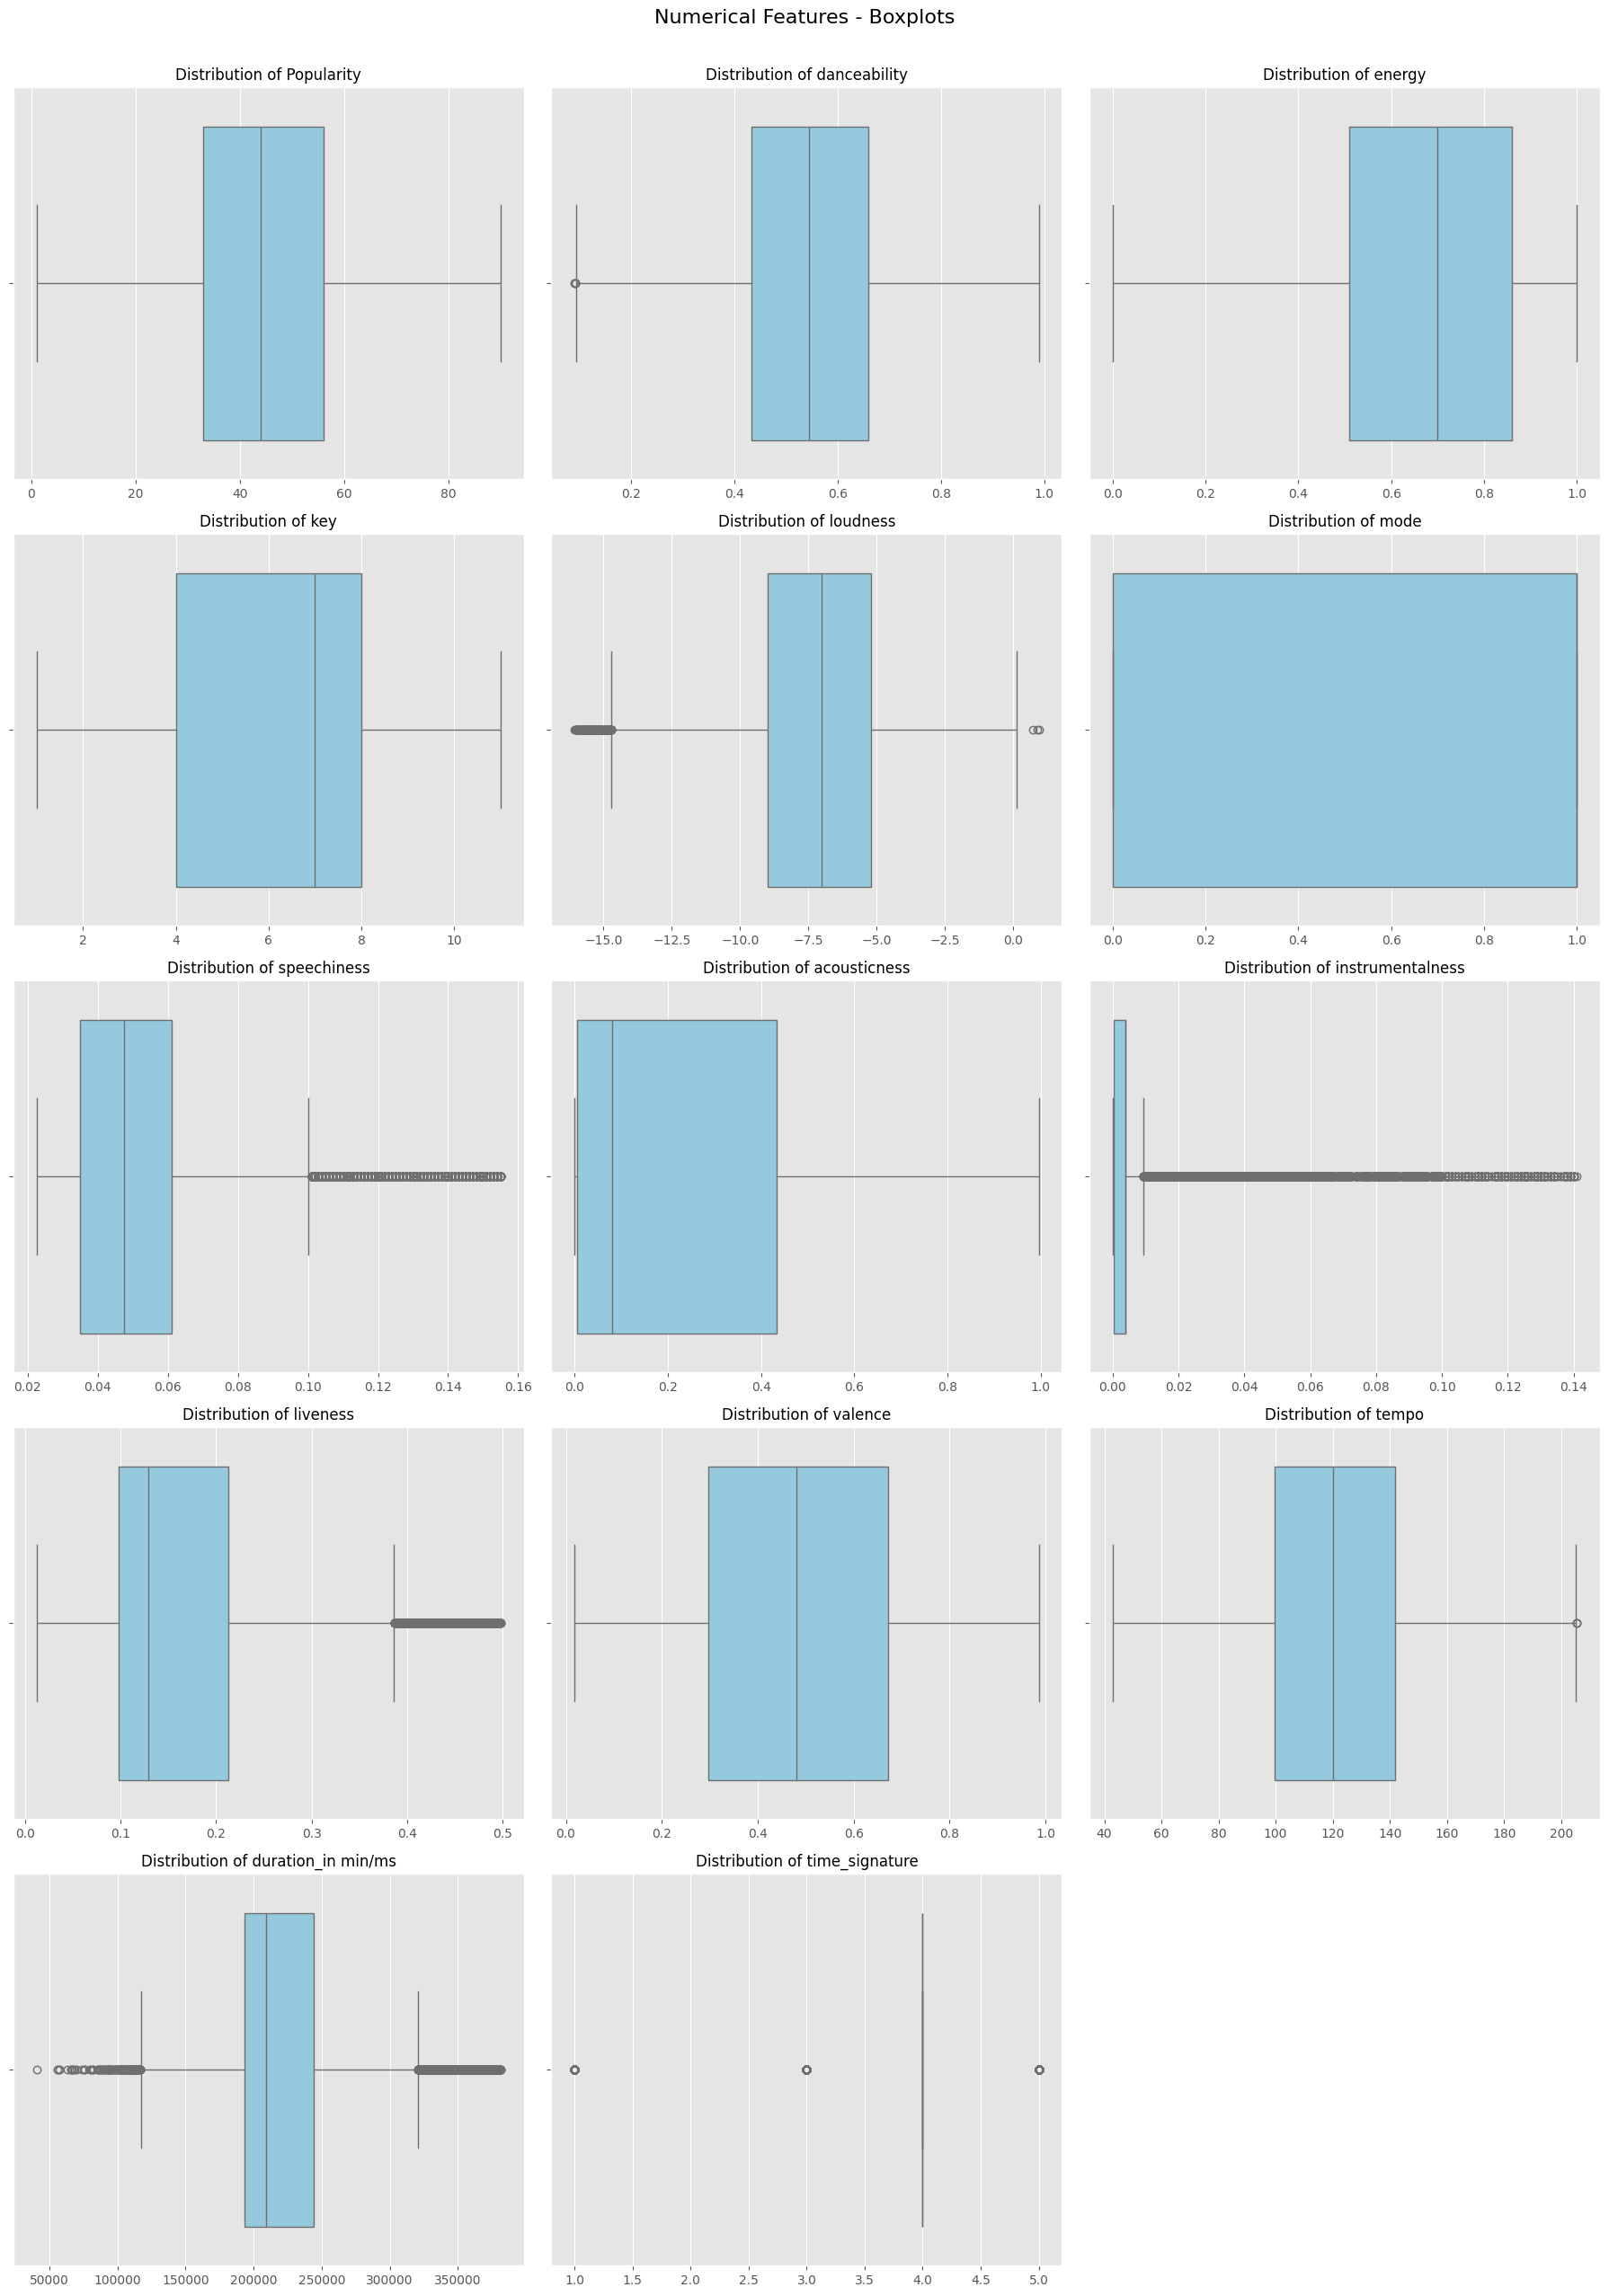

In [19]:
# 5.2 Feature Distributions
print("\n=== Feature Distributions ===")

# Create subplots for numerical features
n_cols = 3
n_rows = int(np.ceil(len(numerical_features) / n_cols))

# Boxplots
plt.figure(figsize=(18, 5*n_rows))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=train_df[col], color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('')
plt.tight_layout()
plt.suptitle('Numerical Features - Boxplots', y=1.02, fontsize=16)
plt.show()


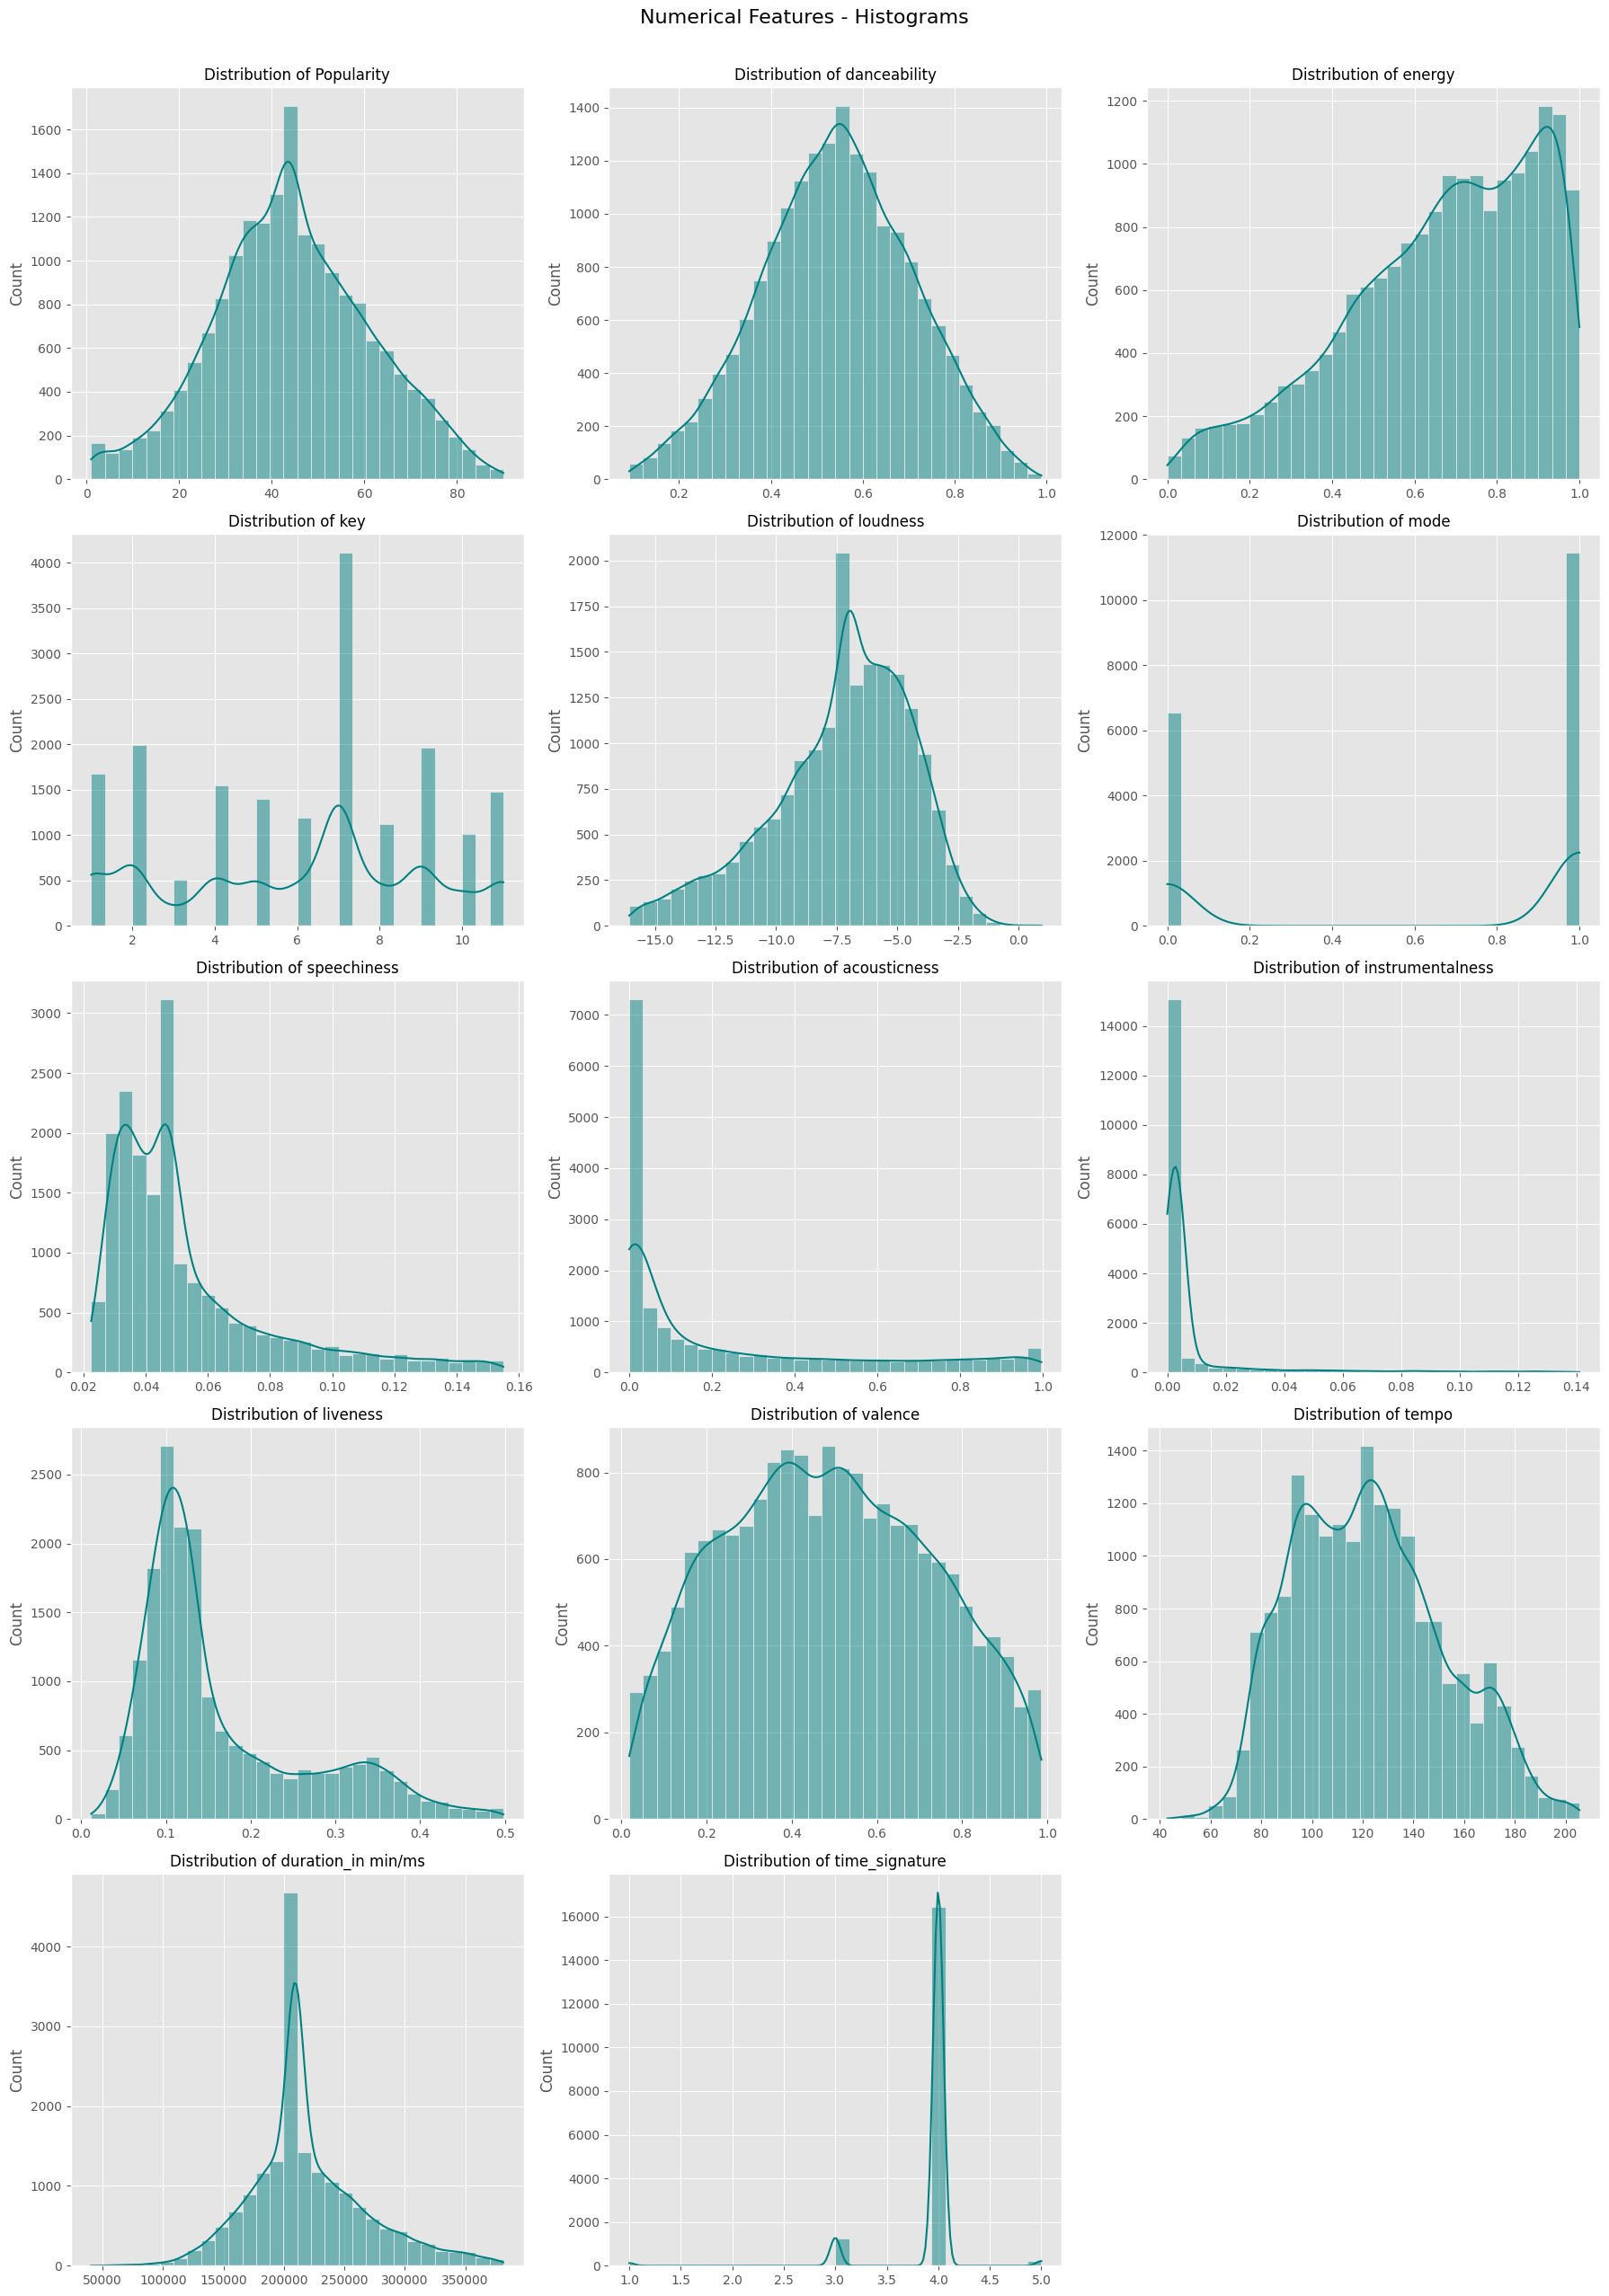

In [20]:
# Histograms
plt.figure(figsize=(18, 5*n_rows))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(train_df[col], bins=30, kde=True, color='teal')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('')
plt.tight_layout()
plt.suptitle('Numerical Features - Histograms', y=1.02, fontsize=16)
plt.show()


In [21]:

print("\n=== Normalizing Numerical Features ===")
scaler = StandardScaler()
train_df[required_col] = scaler.fit_transform(train_df[required_col])
test_df[required_col] = scaler.transform(test_df[required_col])

print("Normalization completed")


=== Normalizing Numerical Features ===
Normalization completed



=== Correlation Analysis ===


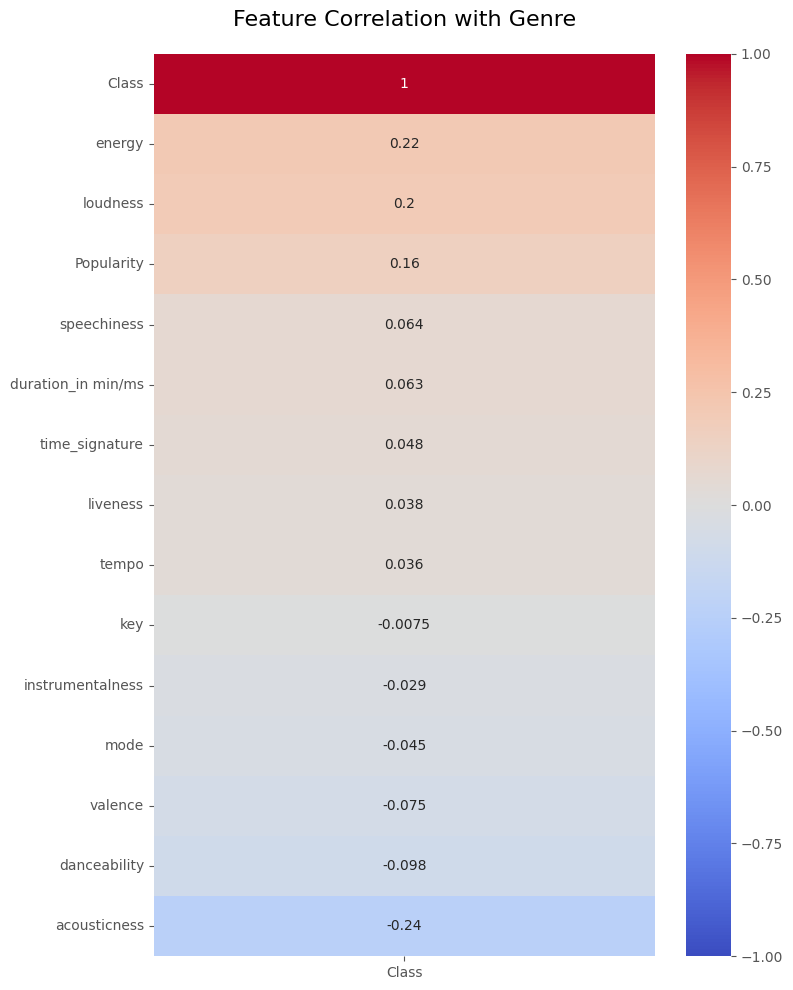

                    Popularity  danceability    energy       key  loudness  \
Popularity            1.000000      0.159396  0.052119  0.003918  0.110516   
danceability          0.159396      1.000000 -0.100406  0.005628 -0.078529   
energy                0.052119     -0.100406  1.000000  0.011090  0.606906   
key                   0.003918      0.005628  0.011090  1.000000  0.000231   
loudness              0.110516     -0.078529  0.606906  0.000231  1.000000   
mode                  0.015862     -0.066560 -0.035880 -0.094606 -0.048236   
speechiness          -0.005239     -0.045157  0.312399 -0.000706  0.204801   
acousticness         -0.125026      0.013703 -0.745963 -0.006544 -0.450791   
instrumentalness     -0.034778     -0.041123  0.023410 -0.018207 -0.038499   
liveness             -0.037913     -0.094771  0.205768 -0.001072  0.132709   
valence               0.053331      0.439292  0.222998  0.031422  0.044203   
tempo                -0.005094     -0.184762  0.212723  0.013450

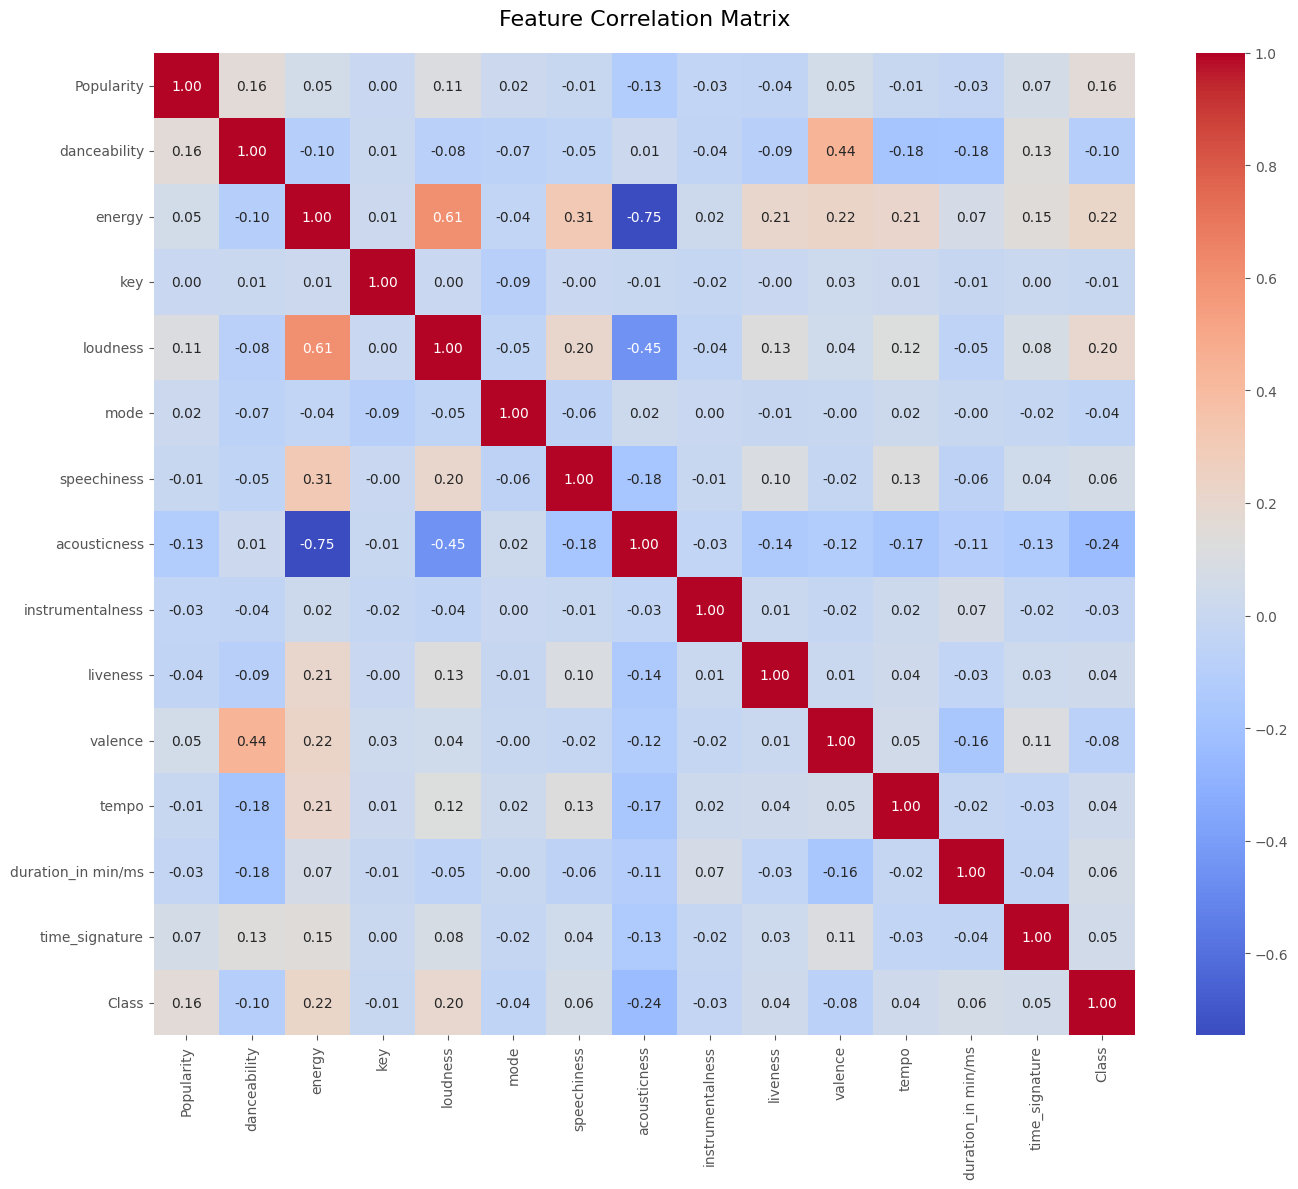

In [22]:
# 5.3 Correlation Analysis
print("\n=== Correlation Analysis ===")

# Correlation with target
corr_with_target = train_df[numerical_features + ['Class']].corr()[['Class']].sort_values('Class', ascending=False)

plt.figure(figsize=(8,10))
sns.heatmap(corr_with_target, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation with Genre', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Full correlation matrix
plt.figure(figsize=(14,12))
corr_matrix = train_df[numerical_features + ['Class']].corr()
print(corr_matrix)
sns.heatmap(corr_matrix, annot=True, fmt=".2f",cmap='coolwarm')
plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()



=== Feature Relationships by Genre ===


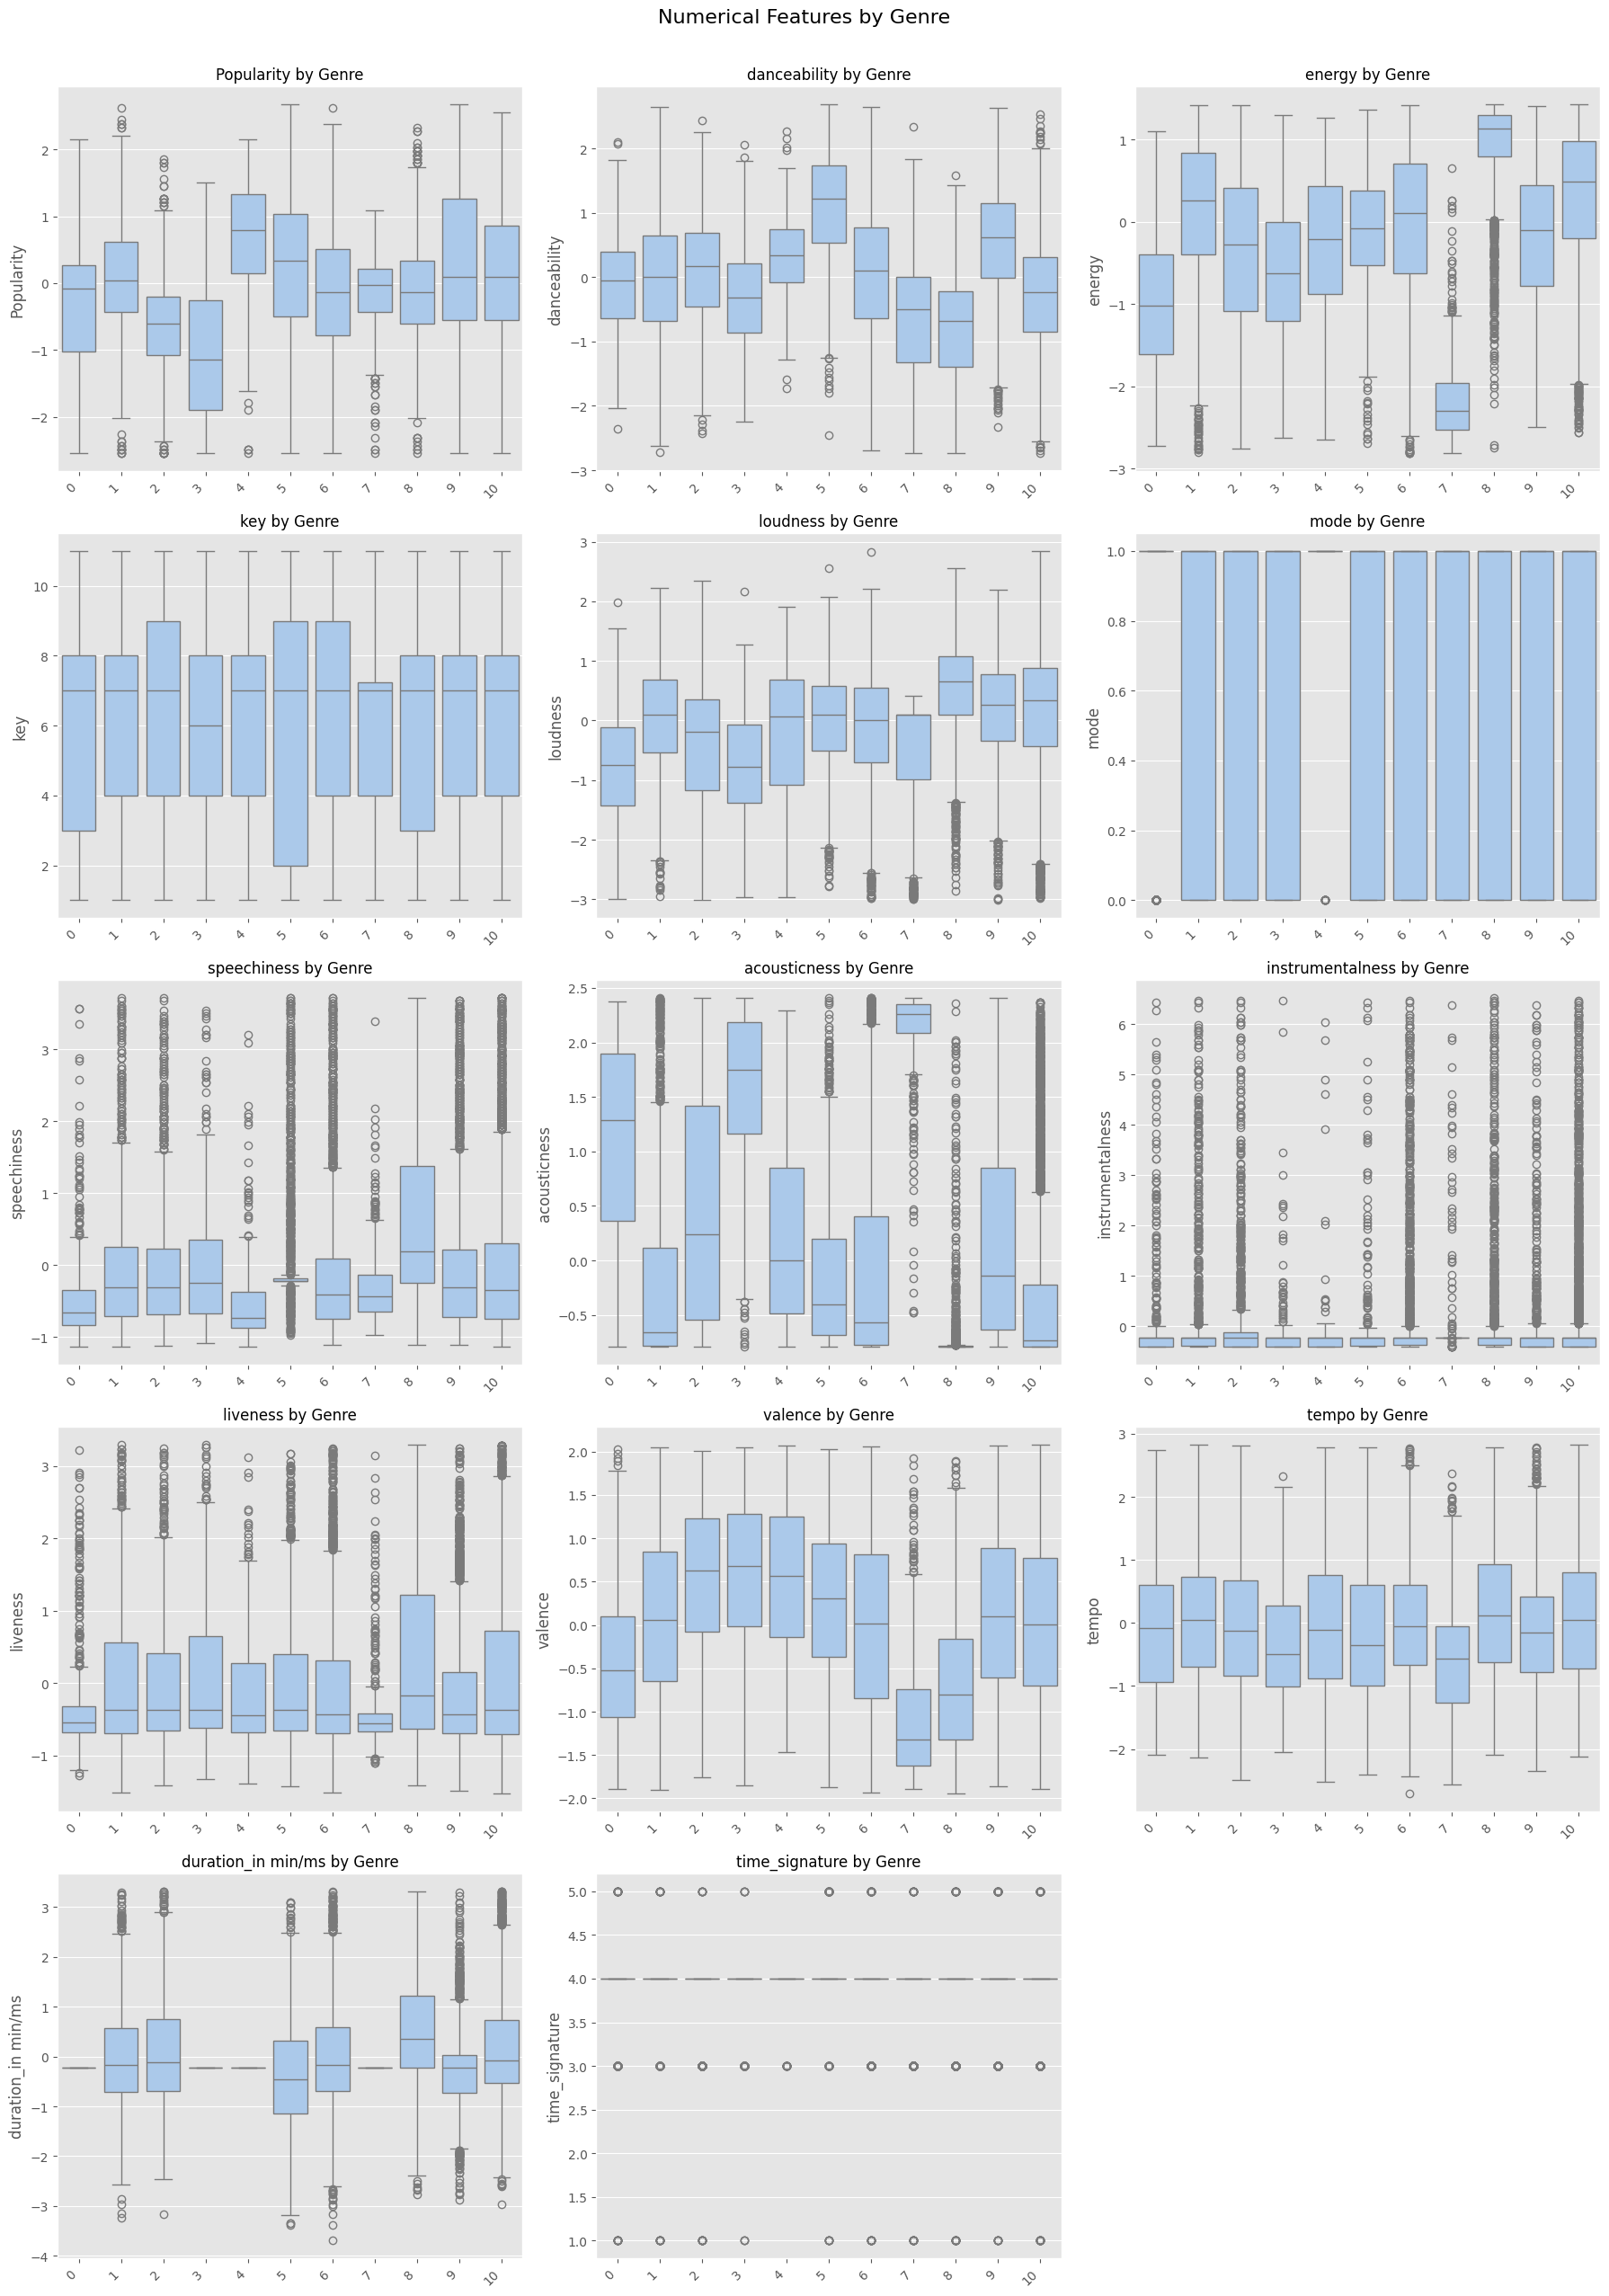

In [23]:
# 5.4 Feature Relationships by Genre
print("\n=== Feature Relationships by Genre ===")

plt.figure(figsize=(18, 5*n_rows))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x='Class', y=col, data=train_df)
    plt.title(f'{col} by Genre', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('')
plt.tight_layout()
plt.suptitle('Numerical Features by Genre', y=1.02, fontsize=16)
plt.show()


=== Pairplot of Key Features ===


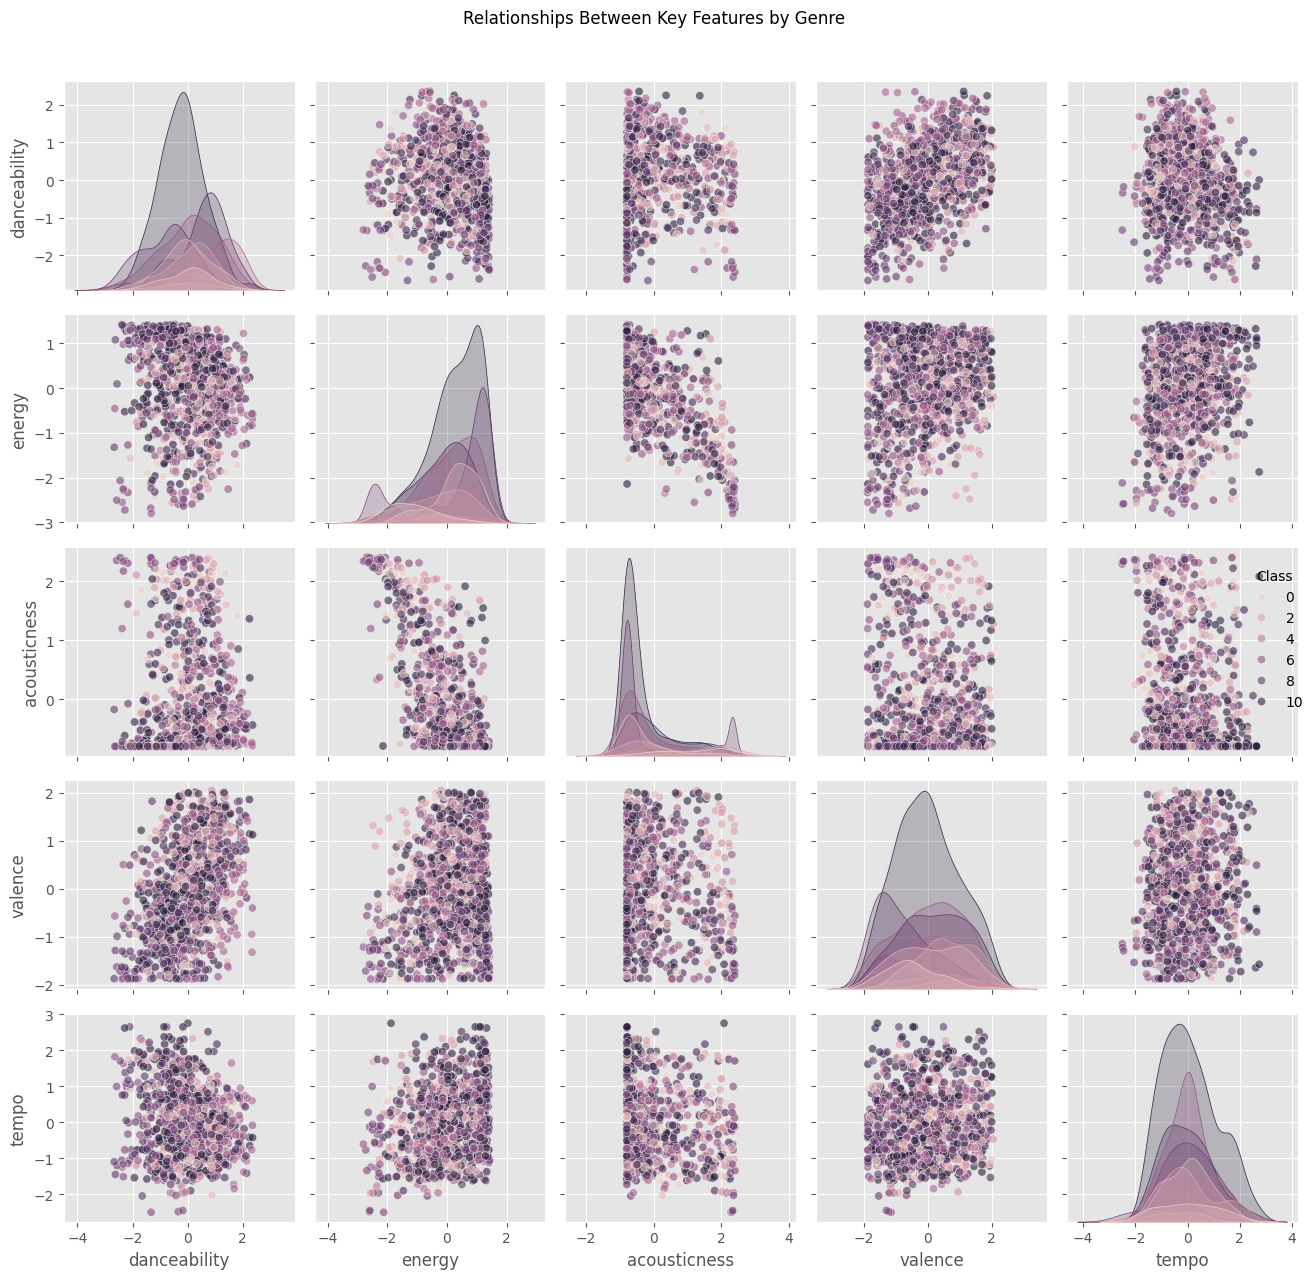

In [24]:
# 5.5 Pairplot of Key Features
print("\n=== Pairplot of Key Features ===")

# Select important features based on correlation
key_features = ['danceability', 'energy', 'acousticness', 'valence', 'tempo', 'Class']
key_features = [f for f in key_features if f in train_df.columns]

# Sample data if large
plot_data = train_df.sample(1000) if len(train_df) > 1000 else train_df

sns.pairplot(plot_data[key_features], hue='Class', diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle('Relationships Between Key Features by Genre', y=1.02)
plt.tight_layout()
plt.show()


In [25]:
train_df['key'].value_counts()

key
7.0     4111
2.0     1994
9.0     1961
1.0     1680
4.0     1549
11.0    1476
5.0     1397
6.0     1190
8.0     1119
10.0    1010
3.0      509
Name: count, dtype: int64

In [26]:
train_df['time_signature'].value_counts()

time_signature
4    16451
3     1228
5      203
1      114
Name: count, dtype: int64

In [27]:
train_df['mode'].value_counts()

mode
1    11459
0     6537
Name: count, dtype: int64

In [28]:
train_df.to_csv('train_df.csv',index=False)

In [29]:
X=train_df.drop('Class',axis=1)
y=train_df['Class']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [30]:
X_train.shape

(12597, 16)

In [31]:
X_val.shape

(5399, 16)